This notebook explores and visualizes descriptive statistics of our filtered corpus

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import os
from collections import Counter
import numpy as np

In [20]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
file_path = "../data/GP_1750_2000_opium_filtered.parquet"
if os.path.exists(file_path):
    df = pd.read_parquet(file_path)
    print(f"Dataset loaded. Shape: {df.shape}")
else:
    print(f"File {file_path} not found.")


Dataset loaded. Shape: (3834, 11)


First we look at the books and their opium mentions:

=== Opium Mentions Analytics ===
Total Books: 3834
Total Opium Mentions: 5744
Average Mentions per Book: 1.50
Median Mentions per Book: 1.0


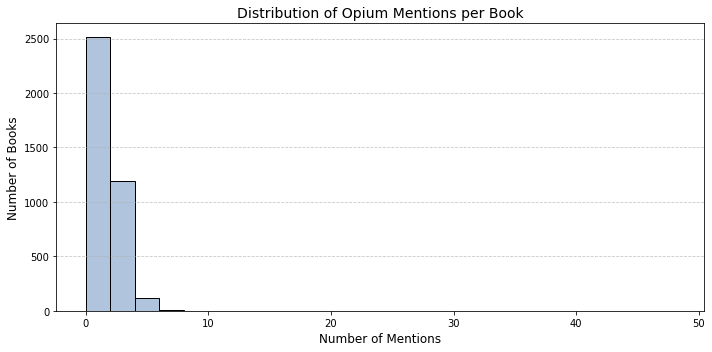

In [3]:
# Opium Mentions Aggregation
if 'Opium Keywords' in df.columns:
    def parse_kws(k):
        if pd.isna(k): return []
        if isinstance(k, np.ndarray): return k.tolist()
        if isinstance(k, list): return k
        try:
            res = ast.literal_eval(k)
            if isinstance(res, list): return res
            return [res]
        except:
            return [x.strip() for x in str(k).split(',')]
            
    df['Opium_Mentions_List'] = df['Opium Keywords'].apply(parse_kws)
    df['Opium_Mention_Count'] = df['Opium_Mentions_List'].apply(len)
    
    print("=== Opium Mentions Analytics ===")
    print(f"Total Books: {len(df)}")
    print(f"Total Opium Mentions: {df['Opium_Mention_Count'].sum()}")
    print(f"Average Mentions per Book: {df['Opium_Mention_Count'].mean():.2f}")
    print(f"Median Mentions per Book: {df['Opium_Mention_Count'].median()}")
    
    plt.figure(figsize=(10, 5))
    df['Opium_Mention_Count'].plot(kind='hist', bins=range(0, max(int(df['Opium_Mention_Count'].max())+2, 50), 2), color='lightsteelblue', edgecolor='black')
    plt.title('Distribution of Opium Mentions per Book', fontsize=14)
    plt.xlabel('Number of Mentions', fontsize=12)
    plt.ylabel('Number of Books', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


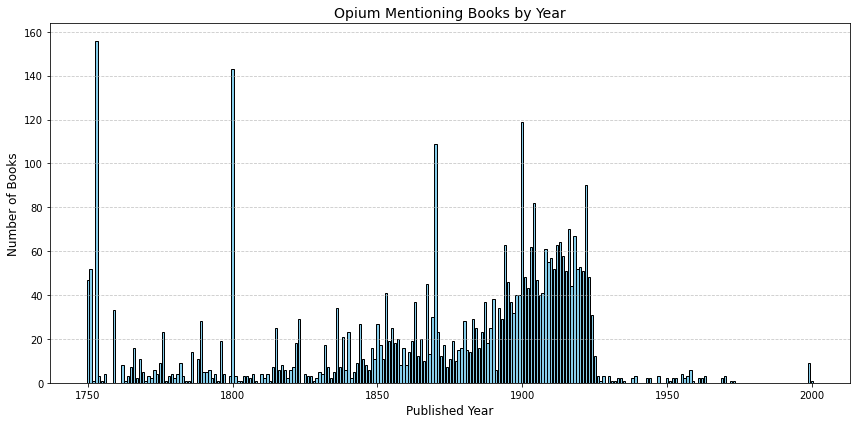

In [ ]:
# Books per year distribution
if 'published_year' in df.columns:
    plt.figure(figsize=(12, 6))
    years = pd.to_numeric(df['published_year'], errors='coerce')
    year_counts = years.dropna().value_counts().sort_index()
    plt.bar(year_counts.index, year_counts.values, color='skyblue', edgecolor='black')
    plt.title('Opium Mentioning Books by Year', fontsize=14)
    plt.xlabel('Published Year', fontsize=12)
    plt.ylabel('Number of Books', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("'published_year' column not found.")


(Top) themes and genres - Absolute count:

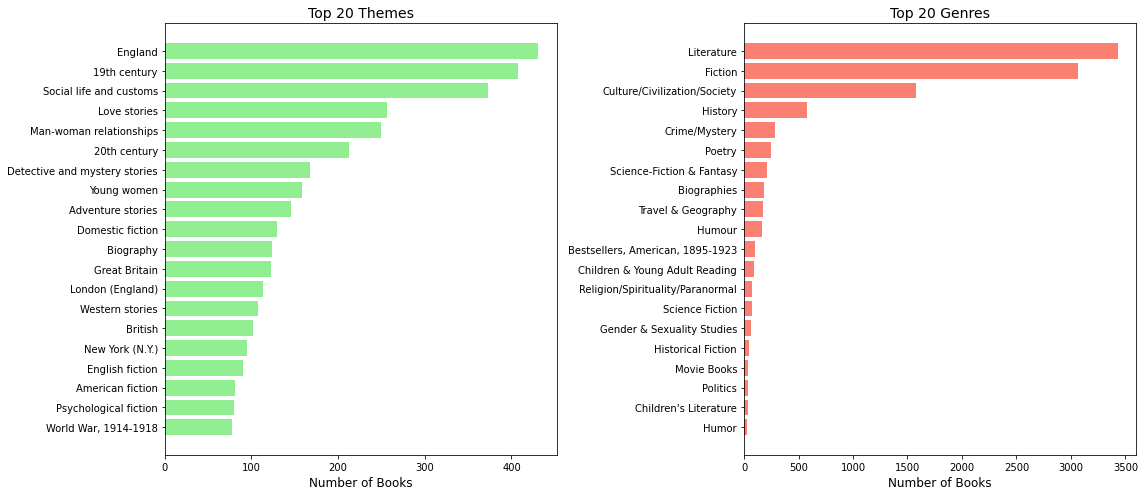

In [8]:
# Top Themes and Genres
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def parse_list(k):
    if isinstance(k, np.ndarray): return k.tolist()
    if isinstance(k, list): return k
    try:
        res = ast.literal_eval(k)
        return res if isinstance(res, list) else [res]
    except:
        return [x.strip() for x in str(k).split(',')]

all_themes = df['Themes'].apply(parse_list).explode().dropna()
top_themes = all_themes.value_counts().head(20)

axes[0].barh(top_themes.index[::-1], top_themes.values[::-1], color='lightgreen')
axes[0].set_title('Top 20 Themes', fontsize=14)
axes[0].set_xlabel('Number of Books', fontsize=12)

all_genres = df['Genres'].apply(parse_list).explode().dropna()
top_genres = all_genres.value_counts().head(20)

axes[1].barh(top_genres.index[::-1], top_genres.values[::-1], color='salmon')
axes[1].set_title('Top 20 Genres', fontsize=14)
axes[1].set_xlabel('Number of Books', fontsize=12)

plt.tight_layout()
plt.show()

Relative (percentage) count:

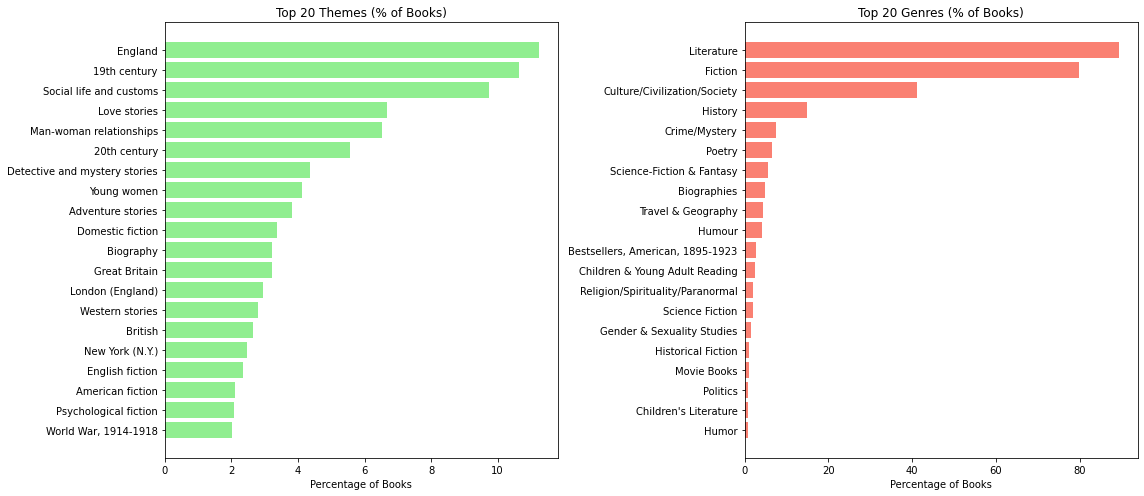

In [29]:
n_books = len(df)
top_themes_pct = top_themes / n_books * 100
top_genres_pct = top_genres / n_books * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Themes
axes[0].barh(top_themes_pct.index[::-1], top_themes_pct.values[::-1], color='lightgreen')
axes[0].set_title('Top 20 Themes (% of Books)')
axes[0].set_xlabel('Percentage of Books')

# Genres
axes[1].barh(top_genres_pct.index[::-1], top_genres_pct.values[::-1], color='salmon')
axes[1].set_title('Top 20 Genres (% of Books)')
axes[1].set_xlabel('Percentage of Books')

plt.tight_layout()
plt.show()

Genres are concentrated around 'Literature' and 'Fiction' (making up >80%, fair since it's our broad main focus), and themes are more diverse

Note that themes and genre can overlap (one book can have multiple themes and genres) - so we can look at their co-occurance, and also accumulative coverage to see dominant factors within these attributes

In [13]:
TOP_N_THEMES = 20 
TOP_N_GENRES = 20

top_theme_list = all_themes.value_counts().head(TOP_N_THEMES).index
top_genre_list = all_genres.value_counts().head(TOP_N_GENRES).index

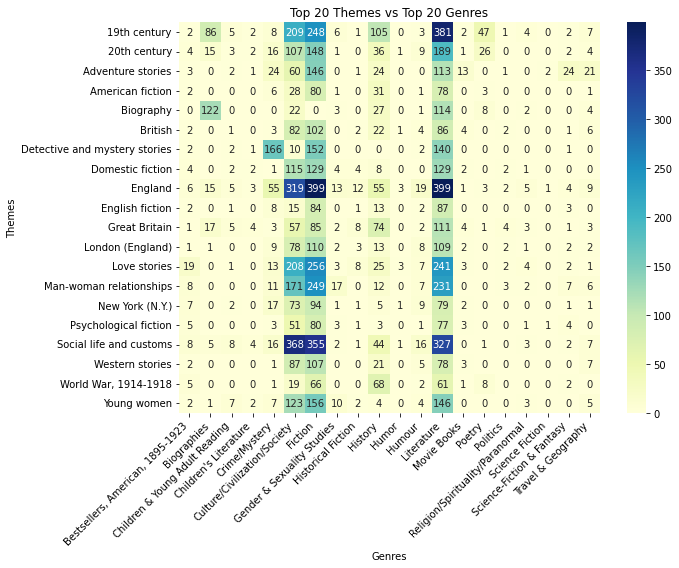

In [18]:
import seaborn as sns

df_exploded = df.explode('Themes').explode('Genres')

# Filter BEFORE building matrix
filtered = df_exploded[
    df_exploded['Themes'].isin(top_theme_list) &
    df_exploded['Genres'].isin(top_genre_list)
]

co_matrix = pd.crosstab(
    filtered['Themes'],
    filtered['Genres']
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    co_matrix,
    cmap='YlGnBu',
    annot=True,        # <-- helps a lot when small
    fmt='d'
)

plt.title(f'Top {TOP_N_THEMES} Themes vs Top {TOP_N_GENRES} Genres')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

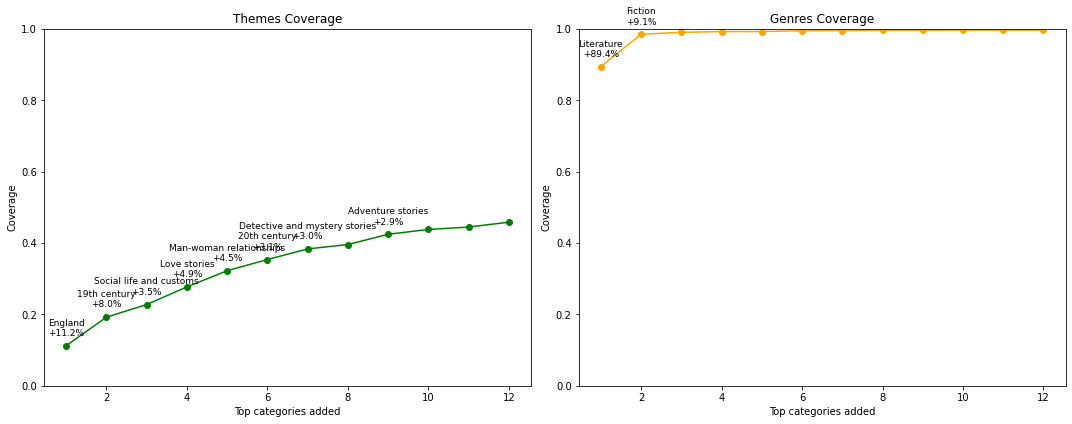

In [ ]:
def cumulative_coverage_with_gain(series, top_n=12):
    parsed = series.apply(parse_list)

    all_items = parsed.explode()
    top_items = all_items.value_counts().head(top_n).index.tolist()

    coverage = []
    gains = []
    selected = set()

    prev_cov = 0

    for item in top_items:
        selected.add(item)

        covered = parsed.apply(lambda x: any(i in x for i in selected))
        curr_cov = covered.mean()

        coverage.append(curr_cov)
        gains.append(curr_cov - prev_cov)

        prev_cov = curr_cov

    return top_items, coverage, gains

themes, theme_cov, theme_gain = cumulative_coverage_with_gain(df['Themes'])
genres, genre_cov, genre_gain = cumulative_coverage_with_gain(df['Genres'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

def plot_with_labels(ax, items, cov, gains, title, color):
    x = range(1, len(items)+1)
    ax.plot(x, cov, marker='o', color=color)

    for i, (item, c, g) in enumerate(zip(items, cov, gains)):
        # Only label meaningful jumps
        if g > 0.02:  # tweak threshold
            ax.annotate(
                f"{item}\n+{g:.1%}",
                (i+1, c),
                textcoords="offset points",
                xytext=(0,10),
                ha='center',
                fontsize=9
            )

    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Top categories added")
    ax.set_ylabel("Coverage")

plot_with_labels(axes[0], themes, theme_cov, theme_gain, "Themes Coverage", "green")
plot_with_labels(axes[1], genres, genre_cov, genre_gain, "Genres Coverage", "orange")

plt.tight_layout()
plt.show()

Now we look a bit deeper into the opium terms themselves:

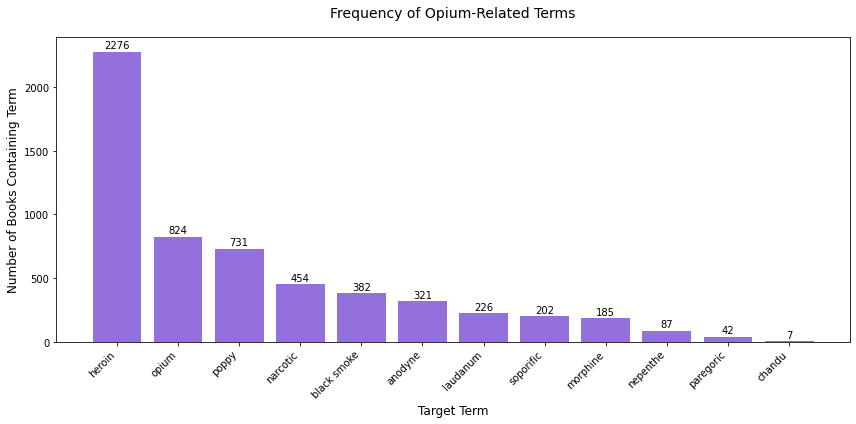

In [31]:
# Term Frequency
if 'Opium Keywords' in df.columns:
    term_counts = Counter()
    for row in df['Opium Keywords']:
        if pd.isna(row): continue
        try:
            keywords = ast.literal_eval(row)
            if isinstance(keywords, list):
                term_counts.update(keywords)
            elif isinstance(keywords, str):
                term_counts.update([keywords])
        except Exception:
            if isinstance(row, str):
                term_counts.update([k.strip() for k in row.split(',')])

    top_terms = dict(term_counts.most_common(12))
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(top_terms.keys(), top_terms.values(), color='mediumpurple')
    plt.title('Frequency of Opium-Related Terms', fontsize=14, pad=20)
    plt.xlabel('Target Term', fontsize=12)
    plt.ylabel('Number of Books Containing Term', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontsize=10)
        
    plt.tight_layout()
    plt.show()


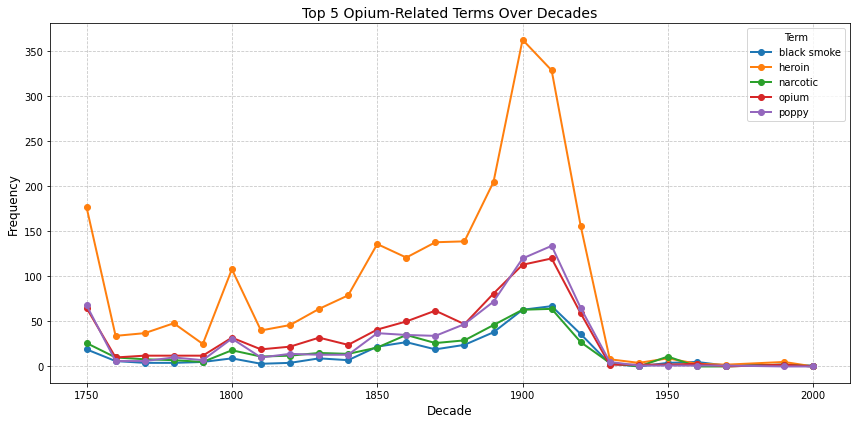

In [32]:
# Terms Over Time (Decades)
if 'Opium Keywords' in df.columns and 'published_year' in df.columns:
    df_terms = df.dropna(subset=['published_year', 'Opium Keywords']).copy()
    df_terms['published_year'] = pd.to_numeric(df_terms['published_year'], errors='coerce')
    df_terms = df_terms.dropna(subset=['published_year'])
    df_terms['decade'] = (df_terms['published_year'] // 10) * 10
    
    records = []
    for idx, row in df_terms.iterrows():
        kw_val = row['Opium Keywords']
        decade = row['decade']
        try:
            kws = ast.literal_eval(kw_val)
            if isinstance(kws, list):
                for k in kws:
                    records.append({'decade': decade, 'term': k})
            elif isinstance(kws, str):
                records.append({'decade': decade, 'term': kws})
        except Exception:
            if isinstance(kw_val, str):
                for k in kw_val.split(','):
                    records.append({'decade': decade, 'term': k.strip()})
                    
    df_expanded = pd.DataFrame(records)
    if not df_expanded.empty:
        top_5_terms = df_expanded['term'].value_counts().head(5).index.tolist()
        df_top5 = df_expanded[df_expanded['term'].isin(top_5_terms)]
        ct = pd.crosstab(df_top5['decade'], df_top5['term'])
        
        plt.figure(figsize=(12, 6))
        for term in ct.columns:
            plt.plot(ct.index, ct[term], marker='o', linewidth=2, label=term)
            
        plt.title('Top 5 Opium-Related Terms Over Decades', fontsize=14)
        plt.xlabel('Decade', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.legend(title='Term')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()


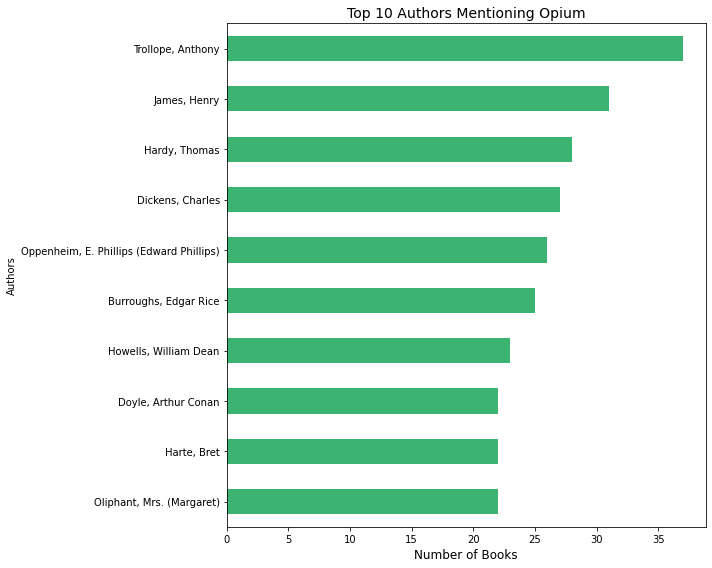

In [33]:
# Top Authors
df_authors = df.dropna(subset=['Authors']).copy()
all_authors = df_authors['Authors'].str.split(';').explode().str.strip()
top_authors = all_authors.value_counts().head(10)

plt.figure(figsize=(10, 8))
top_authors.sort_values().plot(kind='barh', color='mediumseagreen')
plt.title('Top 10 Authors Mentioning Opium', fontsize=14)
plt.xlabel('Number of Books', fontsize=12)
plt.tight_layout()
plt.show()


TODO: re-run this when we have the correct publication year data?